In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

import warnings
warnings.filterwarnings('ignore')

# Make plots appear inside the notebook
%matplotlib inline

# Reproducibility
np.random.seed(42)

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=15
)

# Convert labels: 0 -> -1 and 1 -> +1
y_hinge = np.where(y == 0, -1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique original labels:", np.unique(y))
print("Unique hinge-loss labels:", np.unique(y_hinge))

X shape: (100, 2)
y shape: (100,)
Unique original labels: [0 1]
Unique hinge-loss labels: [-1  1]


In [3]:
# Display a small portion of the dataset
print("First 10 feature rows:")
print(X[:10])

print("\nFirst 10 original labels:")
print(y[:10])

print("\nFirst 10 converted labels:")
print(y_hinge[:10])

First 10 feature rows:
[[ 0.35523945 -0.11697552]
 [-0.09282829 -0.73115232]
 [-0.1984984  -0.7081059 ]
 [-2.44001098 -2.01199214]
 [-0.0448475   1.63493163]
 [-1.68155714  0.15599044]
 [-2.64121606  1.07782053]
 [ 0.2416527   0.80626713]
 [-0.40266099  0.74859527]
 [-2.80888854  0.75152794]]

First 10 original labels:
[1 1 1 0 1 0 0 1 1 0]

First 10 converted labels:
[ 1  1  1 -1  1 -1 -1  1  1 -1]


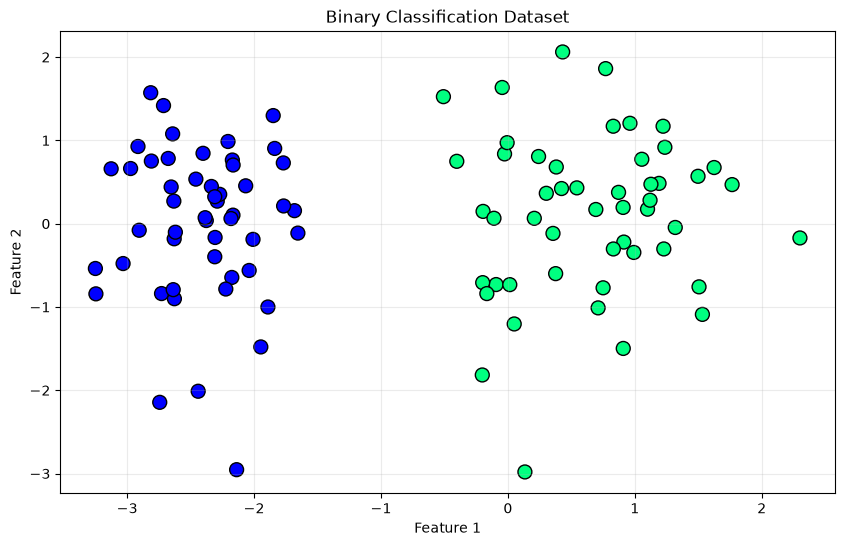

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="winter",
    s=100,
    edgecolor="black"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.grid(alpha=0.25)
plt.show()

In [5]:
def perceptron(X, y, learning_rate=0.1, epochs=1000):
    """Train a binary perceptron from scratch.

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
        Training features.
    y : ndarray, shape (n_samples,)
        Labels expected in {-1, +1}.
    learning_rate : float
        Size of each parameter update.
    epochs : int
        Number of complete passes through the dataset.

    Returns
    -------
    weights : ndarray
        Learned feature weights.
    bias : float
        Learned bias.
    errors_history : list
        Number of mistakes in every epoch.
    """

    n_samples, n_features = X.shape

    # Initialize weights and bias
    weights = np.ones(n_features, dtype=float)
    bias = 1.0

    errors_history = []

    for epoch in range(epochs):
        errors = 0

        for i in range(n_samples):
            # Linear score
            z = np.dot(X[i], weights) + bias

            # Perceptron update if prediction is incorrect
            if y[i] * z <= 0:
                weights += learning_rate * y[i] * X[i]
                bias += learning_rate * y[i]
                errors += 1

        errors_history.append(errors)

        # Stop early if every sample is correctly classified
        if errors == 0:
            print(f"Perceptron converged at epoch {epoch + 1}.")
            break

    return weights, bias, errors_history

In [6]:
perceptron_weights, perceptron_bias, perceptron_errors = perceptron(
    X,
    y_hinge,
    learning_rate=0.1,
    epochs=1000
)

print("Perceptron weights:", perceptron_weights)
print("Perceptron bias:", perceptron_bias)


Perceptron converged at epoch 2.
Perceptron weights: [1.17813614 0.39049057]
Perceptron bias: 1.1


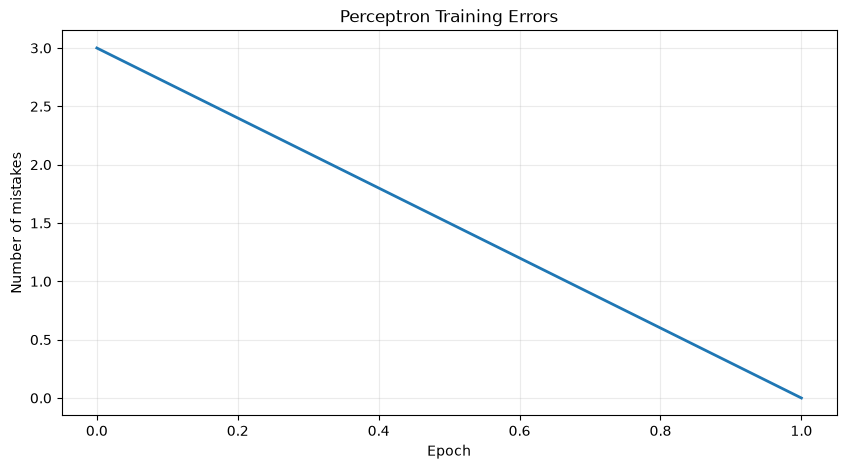

In [7]:
# Plot the number of mistakes made in each epoch
plt.figure(figsize=(10, 5))
plt.plot(perceptron_errors, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Number of mistakes")
plt.title("Perceptron Training Errors")
plt.grid(alpha=0.25)
plt.show()

In [8]:
def hinge_loss(y_true, scores):
    """Return the average hinge loss.

    y_true must contain -1 and +1.
    scores are the raw linear model outputs.
    """
    margins = y_true * scores
    losses = np.maximum(0, 1 - margins)
    return np.mean(losses)


def individual_hinge_losses(y_true, scores):
    """Return hinge loss for each observation."""
    margins = y_true * scores
    return np.maximum(0, 1 - margins)


In [9]:
# Example: inspect hinge loss for several margins

example_margins = np.array([-2.0, -0.5, 0.2, 0.8, 1.0, 1.5, 3.0])

# Since margin = y * score, hinge loss is simply max(0, 1 - margin)
example_losses = np.maximum(0, 1 - example_margins)

for margin, loss in zip(example_margins, example_losses):
    print(f"Margin = {margin:>4}: Hinge loss = {loss:.2f}")

Margin = -2.0: Hinge loss = 3.00
Margin = -0.5: Hinge loss = 1.50
Margin =  0.2: Hinge loss = 0.80
Margin =  0.8: Hinge loss = 0.20
Margin =  1.0: Hinge loss = 0.00
Margin =  1.5: Hinge loss = 0.00
Margin =  3.0: Hinge loss = 0.00


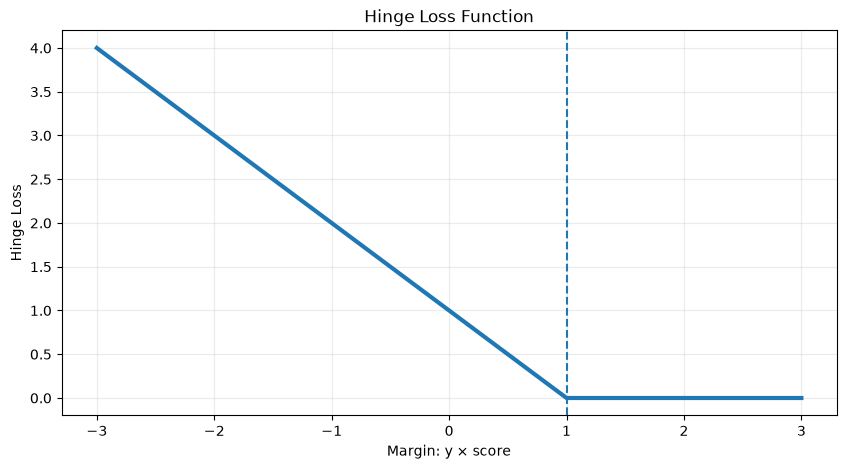

In [10]:
margins = np.linspace(-3, 3, 400)
loss_values = np.maximum(0, 1 - margins)

plt.figure(figsize=(10, 5))
plt.plot(margins, loss_values, linewidth=3)
plt.axvline(1, linestyle="--", linewidth=1.5)
plt.xlabel("Margin: y × score")
plt.ylabel("Hinge Loss")
plt.title("Hinge Loss Function")
plt.grid(alpha=0.25)
plt.show()


In [11]:
def hinge_perceptron(
    X,
    y,
    learning_rate=0.01,
    epochs=100,
    l2_strength=0.001
):
    """Train a linear classifier using regularized hinge loss.

    The labels must be -1 and +1.

    Objective:
        average hinge loss + (lambda / 2) * ||w||^2

    Returns
    -------
    weights : ndarray
        Learned feature weights.
    bias : float
        Learned bias.
    history : dict
        Training metrics for every epoch.
    """

    n_samples, n_features = X.shape

    weights = np.zeros(n_features, dtype=float)
    bias = 0.0

    loss_history = []
    margin_violation_history = []
    accuracy_history = []

    for epoch in range(epochs):
        # Shuffle observations at the beginning of every epoch
        indices = np.random.permutation(n_samples)

        for i in indices:
            x_i = X[i]
            y_i = y[i]

            # Raw model score
            score = np.dot(weights, x_i) + bias

            # Margin
            margin = y_i * score

            if margin < 1:
                # Hinge-loss gradient/sub-gradient
                weights = (
                    (1 - learning_rate * l2_strength) * weights
                    + learning_rate * y_i * x_i
                )
                bias = bias + learning_rate * y_i
            else:
                # Only regularization affects weights
                weights = (1 - learning_rate * l2_strength) * weights

        # Calculate metrics after this epoch
        scores = X @ weights + bias
        losses = np.maximum(0, 1 - y * scores)

        average_hinge_loss = np.mean(losses)
        regularization = (l2_strength / 2) * np.sum(weights ** 2)
        total_objective = average_hinge_loss + regularization

        predictions = np.where(scores >= 0, 1, -1)
        accuracy = np.mean(predictions == y)

        margin_violations = np.sum((y * scores) < 1)

        loss_history.append(total_objective)
        margin_violation_history.append(margin_violations)
        accuracy_history.append(accuracy)

    history = {
        "loss": loss_history,
        "margin_violations": margin_violation_history,
        "accuracy": accuracy_history,
    }

    return weights, bias, history

In [12]:
hinge_weights, hinge_bias, history = hinge_perceptron(
    X,
    y_hinge,
    learning_rate=0.01,
    epochs=100,
    l2_strength=0.001
)

print("Hinge-loss weights:", hinge_weights)
print("Hinge-loss bias:", hinge_bias)
print("Final objective:", history["loss"][-1])
print("Final accuracy:", history["accuracy"][-1])
print("Final margin violations:", history["margin_violations"][-1])

Hinge-loss weights: [1.56436173 0.1324411 ]
Hinge-loss bias: 1.6000000000000012
Final objective: 0.0012323841277614212
Final accuracy: 1.0
Final margin violations: 0


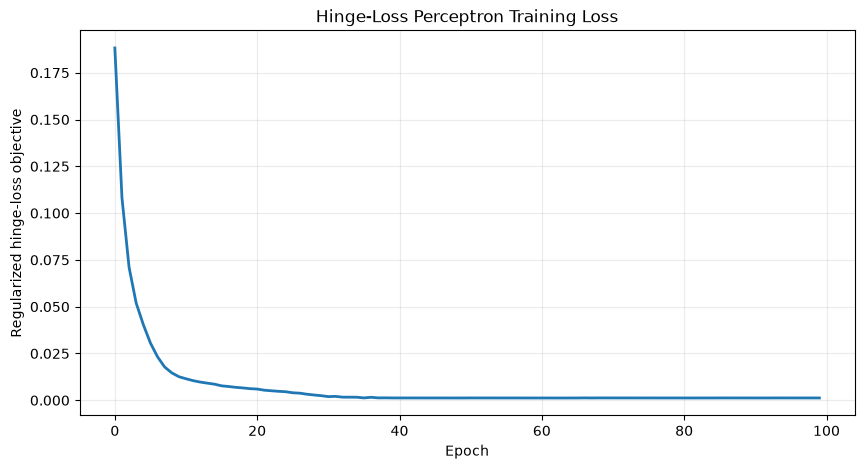

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(history["loss"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Regularized hinge-loss objective")
plt.title("Hinge-Loss Perceptron Training Loss")
plt.grid(alpha=0.25)
plt.show()


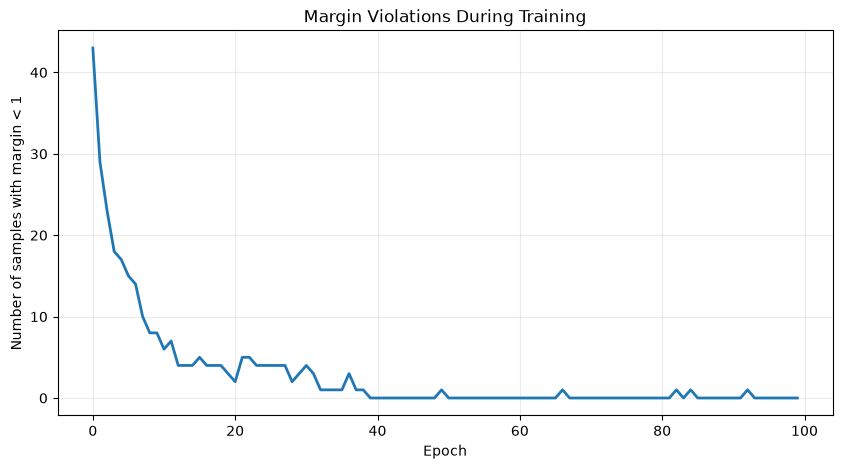

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history["margin_violations"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Number of samples with margin < 1")
plt.title("Margin Violations During Training")
plt.grid(alpha=0.25)
plt.show()


In [15]:
def predict_scores(X, weights, bias):
    """Return raw linear scores."""
    X = np.asarray(X)
    return X @ weights + bias


def predict_hinge(X, weights, bias):
    """Return class predictions in {-1, +1}."""
    scores = predict_scores(X, weights, bias)
    return np.where(scores >= 0, 1, -1)


In [16]:
# Training-set predictions
train_scores = predict_scores(X, hinge_weights, hinge_bias)
train_predictions = predict_hinge(X, hinge_weights, hinge_bias)

train_accuracy = np.mean(train_predictions == y_hinge)

print("Training accuracy:", train_accuracy)
print("First 10 scores:", train_scores[:10])
print("First 10 predictions:", train_predictions[:10])
print("First 10 true labels:", y_hinge[:10])

Training accuracy: 1.0
First 10 scores: [ 2.14023063  1.35794837  1.19569439 -2.48353024  1.74637442 -1.00990409
 -2.38906958  2.08481514  1.06923733 -2.69458455]
First 10 predictions: [ 1  1  1 -1  1 -1 -1  1  1 -1]
First 10 true labels: [ 1  1  1 -1  1 -1 -1  1  1 -1]


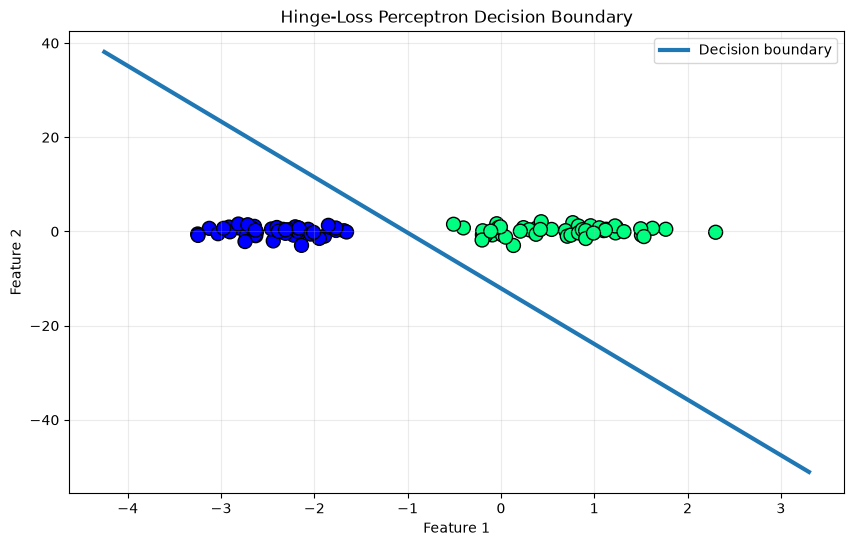

Slope: -11.811754672381579
Intercept: -12.080842399763636


In [17]:
def plot_decision_boundary(X, y, weights, bias, title):
    """Plot the dataset and the linear decision boundary."""

    if np.isclose(weights[1], 0):
        raise ValueError("The second weight is too close to zero to draw y as a function of x.")

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x_input = np.linspace(x_min, x_max, 200)

    slope = -(weights[0] / weights[1])
    intercept = -(bias / weights[1])

    y_input = slope * x_input + intercept

    plt.figure(figsize=(10, 6))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="winter",
        s=100,
        edgecolor="black"
    )

    plt.plot(
        x_input,
        y_input,
        linewidth=3,
        label="Decision boundary"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    print("Slope:", slope)
    print("Intercept:", intercept)


plot_decision_boundary(
    X,
    y,
    hinge_weights,
    hinge_bias,
    "Hinge-Loss Perceptron Decision Boundary"
)

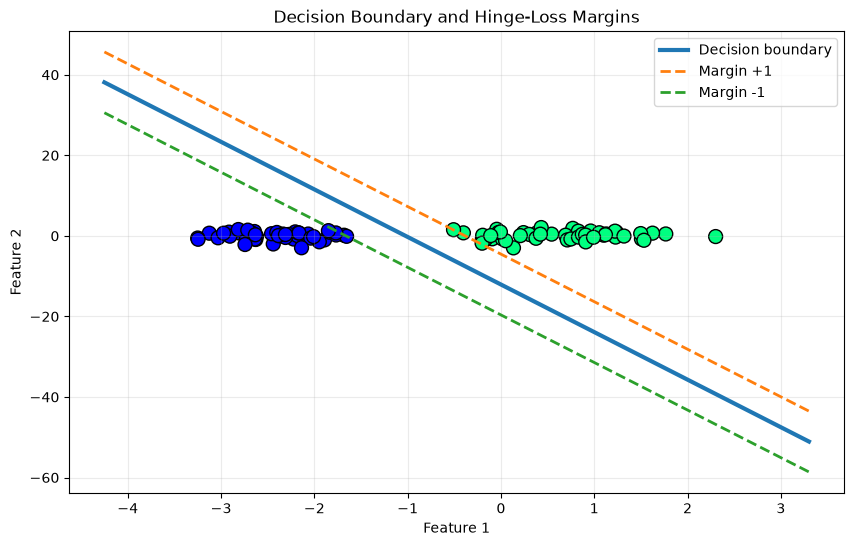

In [18]:
def plot_margin_lines(X, y, weights, bias, title):
    """Plot decision boundary and the two theoretical margin lines."""

    if np.isclose(weights[1], 0):
        raise ValueError("The second weight is too close to zero to draw margin lines.")

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x_input = np.linspace(x_min, x_max, 300)

    w1, w2 = weights

    decision = -(w1 * x_input + bias) / w2
    upper_margin = -(w1 * x_input + bias - 1) / w2
    lower_margin = -(w1 * x_input + bias + 1) / w2

    plt.figure(figsize=(10, 6))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="winter",
        s=100,
        edgecolor="black"
    )

    plt.plot(x_input, decision, linewidth=3, label="Decision boundary")
    plt.plot(x_input, upper_margin, linestyle="--", linewidth=2, label="Margin +1")
    plt.plot(x_input, lower_margin, linestyle="--", linewidth=2, label="Margin -1")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


plot_margin_lines(
    X,
    y,
    hinge_weights,
    hinge_bias,
    "Decision Boundary and Hinge-Loss Margins"
)

In [19]:
losses = individual_hinge_losses(y_hinge, train_scores)
margins = y_hinge * train_scores

results = np.column_stack([
    y_hinge,
    train_scores,
    margins,
    losses
])

print("  y      score      margin      hinge_loss")
print("-" * 48)

for row in results[:15]:
    print(
        f"{int(row[0]):>3} "
        f"{row[1]:>10.4f} "
        f"{row[2]:>11.4f} "
        f"{row[3]:>12.4f}"
    )

print("\nAverage hinge loss:", np.mean(losses))

  y      score      margin      hinge_loss
------------------------------------------------
  1     2.1402      2.1402       0.0000
  1     1.3579      1.3579       0.0000
  1     1.1957      1.1957       0.0000
 -1    -2.4835      2.4835       0.0000
  1     1.7464      1.7464       0.0000
 -1    -1.0099      1.0099       0.0000
 -1    -2.3891      2.3891       0.0000
  1     2.0848      2.0848       0.0000
  1     1.0692      1.0692       0.0000
 -1    -2.6946      2.6946       0.0000
 -1    -2.6296      2.6296       0.0000
 -1    -2.5368      2.5368       0.0000
  1     1.4149      1.4149       0.0000
  1     3.2639      3.2639       0.0000
 -1    -2.4828      2.4828       0.0000

Average hinge loss: 0.0


In [20]:
new_points = np.array([
    [-2.0, 0.0],
    [0.0, 0.5],
    [2.0, 0.0],
    [4.0, -0.5]
])

new_scores = predict_scores(new_points, hinge_weights, hinge_bias)
new_predictions = predict_hinge(new_points, hinge_weights, hinge_bias)

for point, score, prediction in zip(new_points, new_scores, new_predictions):
    class_label = 1 if prediction == 1 else 0

    print(
        f"Input={point}, "
        f"score={score:.4f}, "
        f"hinge_label={prediction:+d}, "
        f"original_class={class_label}"
    )

Input=[-2.  0.], score=-1.5287, hinge_label=-1, original_class=0
Input=[0.  0.5], score=1.6662, hinge_label=+1, original_class=1
Input=[2. 0.], score=4.7287, hinge_label=+1, original_class=1
Input=[ 4.  -0.5], score=7.7912, hinge_label=+1, original_class=1


In [21]:
# Train the classic perceptron
p_weights, p_bias, _ = perceptron(
    X,
    y_hinge,
    learning_rate=0.1,
    epochs=1000
)

# Predictions
p_predictions = predict_hinge(X, p_weights, p_bias)
h_predictions = predict_hinge(X, hinge_weights, hinge_bias)

# Accuracies
p_accuracy = np.mean(p_predictions == y_hinge)
h_accuracy = np.mean(h_predictions == y_hinge)

# Margins
p_scores = predict_scores(X, p_weights, p_bias)
h_scores = predict_scores(X, hinge_weights, hinge_bias)

p_margin_violations = np.sum(y_hinge * p_scores < 1)
h_margin_violations = np.sum(y_hinge * h_scores < 1)

print("Classic Perceptron")
print("Accuracy:", p_accuracy)
print("Margin violations:", p_margin_violations)

print("\nHinge-Loss Perceptron")
print("Accuracy:", h_accuracy)
print("Margin violations:", h_margin_violations)

Perceptron converged at epoch 2.
Classic Perceptron
Accuracy: 1.0
Margin violations: 16

Hinge-Loss Perceptron
Accuracy: 1.0
Margin violations: 0


In [22]:
from sklearn.svm import LinearSVC

sk_model = LinearSVC(
    C=1.0,
    loss="hinge",
    max_iter=10000,
    random_state=42
)

sk_model.fit(X, y_hinge)

sk_predictions = sk_model.predict(X)
sk_accuracy = np.mean(sk_predictions == y_hinge)

print("Scikit-learn LinearSVC accuracy:", sk_accuracy)
print("Scikit-learn weights:", sk_model.coef_.ravel())
print("Scikit-learn bias:", sk_model.intercept_[0])

Scikit-learn LinearSVC accuracy: 1.0
Scikit-learn weights: [1.4600942  0.19894849]
Scikit-learn bias: 1.438278227562675
